In [ ]:
# BLOCO 01 - IMPORTAÇÃO DAS BIBLIOTECAS UTILIZADAS NO PROJETO.

import pandas as pd  # type: ignore
import numpy as np  # type: ignore
import matplotlib.pyplot as plt  # type: ignore
import seaborn as sns  # type: ignore
import joblib  # type: ignore
import shap  # type: ignore

from sklearn.model_selection import ( # type: ignore
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.pipeline import Pipeline # type: ignore
from sklearn.preprocessing import StandardScaler, LabelEncoder # type: ignore

from sklearn.metrics import ( # type: ignore
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.naive_bayes import GaussianNB  # type: ignore
from sklearn.neighbors import KNeighborsClassifier  # type: ignore
from sklearn.svm import SVC  # type: ignore
from sklearn.ensemble import (  # type: ignore
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier # type: ignore

/home/cristiano/miniconda3/envs/sime/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# BLOCO 02 - CARREGAMENTO DA BASE PARA ANÁLISE.

df = pd.read_csv(
    "/home/cristiano/projeto_sirca/sirca_model/dataset_crop_recommendation/Crop_recommendation.csv")

print(df.shape)
df.head()

(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
# BLOCO 03 - ANÁLISE EXPLORATÓRIA DOS DADOS.

print(df.info())
print("\n")
print(df.isnull().sum())
print("\n")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
None


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931 

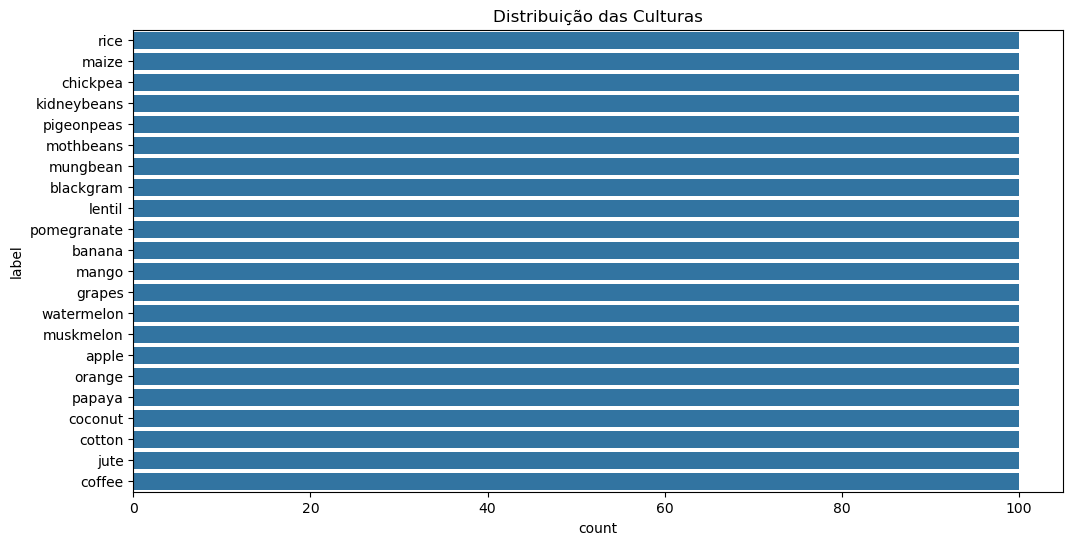

In [5]:
# BLOCO 04 - DISTRIBUIÇÃO DAS CULTURAS.

plt.figure(figsize=(12, 6))

sns.countplot(
    y='label',
    data=df,
    order=df['label'].value_counts().index
)

plt.title('Distribuição das Culturas')
plt.show()

In [6]:
# BLOCO 05 - SEPARAÇÃO DAS VARIÁVEIS.

X = df.drop('label', axis=1)
y = df['label']

In [7]:
# BLOCO 06 - DIVISÃO DE TREINO/TESTE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [8]:
# BLOCO 07 - DEFINIÇÃO DOS MODELOS.

models = {

    'GaussianNB':
    Pipeline([
        ('model', GaussianNB())
    ]),

    'KNN':
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),

    'SVM':
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC())
    ]),

    'RandomForest':
    Pipeline([
        ('model',
         RandomForestClassifier(
             random_state=42
         ))
    ]),

    'GradientBoosting':
    Pipeline([
        ('model',
         GradientBoostingClassifier(
             random_state=42
         ))
    ])
}

In [9]:
# BLOCO 08 -  VALIDAÇÃO CRUZADA.

results = []

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_weighted'
    )

    results.append([
        name,
        scores.mean(),
        scores.std()
    ])

In [10]:
# BLOCO 09 - COMPARAÇÃO DOS MODELOS.

results_df = pd.DataFrame(
    results,
    columns=[
        'Modelo',
        'F1 Médio',
        'Desvio'
    ]
)

results_df = results_df.sort_values(
    by='F1 Médio',
    ascending=False
)

print(results_df)

             Modelo  F1 Médio    Desvio
0        GaussianNB  0.994857  0.004750
3      RandomForest  0.994853  0.004756
4  GradientBoosting  0.990876  0.003782
2               SVM  0.978226  0.011618
1               KNN  0.968347  0.015140


In [11]:
# BLOCO 10 - SELEÇÃO DO MELHOR MODELO.

rf_pipeline = Pipeline([
    (
        'model',
        RandomForestClassifier(
            random_state=42
        )
    )
])

param_grid = {

    'model__n_estimators':
    [100, 200, 300],

    'model__max_depth':
    [10, 20, None],

    'model__min_samples_split':
    [2, 5, 10]
}

In [12]:
# BLOCO 11 - APLICAÇÃO DO GRID SEARCH (BUSCA EM GRADE).

grid_rf = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=param_grid,

    cv=10,

    scoring='f1_weighted',

    n_jobs=-1
)

grid_rf.fit(
    X_train,
    y_train
)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 300}
0.9954275952805365


In [13]:
encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

In [14]:
best_model = grid_rf.best_estimator_

In [15]:
# BLOCO 12 - TREINAMENTO FINAL.

best_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](22,)","['apple','banana','blackgram',...,'pomegranate','rice','watermelon']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['N','P','K',...,'humidity','ph','rainfall']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5


In [16]:
# PREDIÇÕES.

y_pred = best_model.predict(
    X_test
)

In [17]:
# BLOCO 13 - MÉTRICAS AVALIATIVAS DO MODELO.

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Métricas avaliativas do RandomForestClassifier:")
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1: {f1:.4f}')

Métricas avaliativas do RandomForestClassifier:
Accuracy: 0.9932
Precision: 0.9935
Recall: 0.9932
F1: 0.9932


In [18]:
# BLOCO 14 - RELATÓRIO DE CLASSIFICAÇÃO.

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

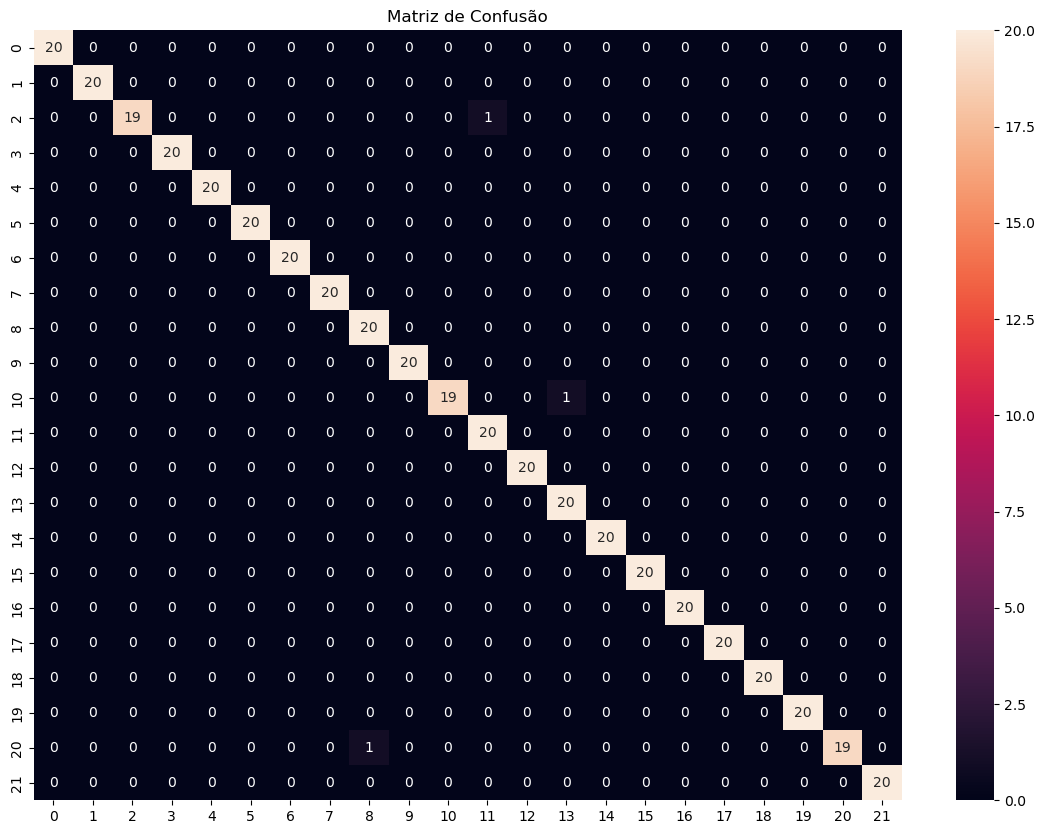

In [19]:
# BLOCO 15 - MATRIZ DE CONFUSÃO.

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Matriz de Confusão'
)

plt.show()

In [20]:
# BLOCO 16 - IMPORTÂNCIA DAS VARIÁVEIS.

rf = best_model.named_steps['model']

importance = pd.DataFrame({

    'Variável': X.columns,

    'Importância': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importância',
    ascending=False
)

print(importance)

      Variável  Importância
6     rainfall     0.218144
4     humidity     0.217062
2            K     0.183533
1            P     0.152992
0            N     0.103720
3  temperature     0.074878
5           ph     0.049671


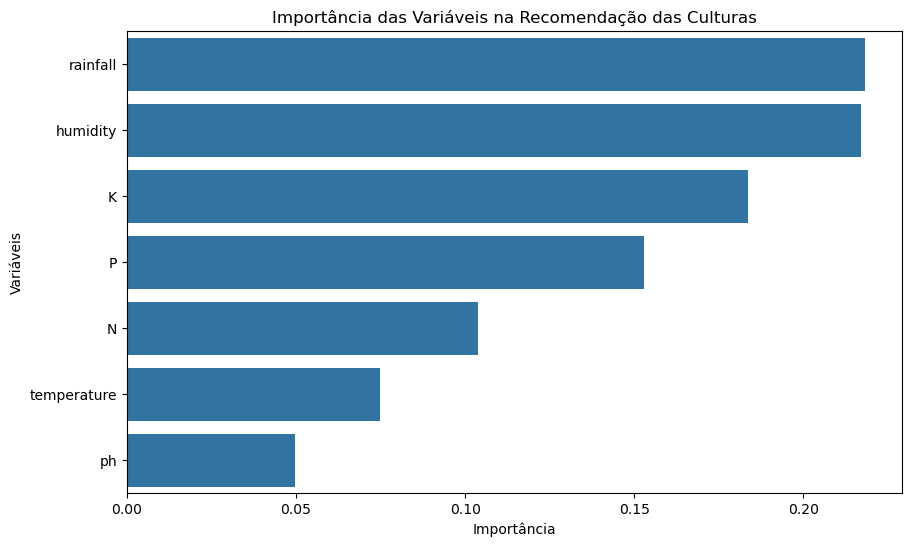

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x='Importância',
    y='Variável'
)

plt.title(
    'Importância das Variáveis na Recomendação das Culturas'
)

plt.xlabel('Importância')

plt.ylabel('Variáveis')

plt.show()

In [22]:
# CONFIGURAÇÃO DO SHAP.

explainer = shap.Explainer(
    rf,
    X_train
)

In [23]:
# BLOCO 17 - PERFIS MÉDIOS DAS CULTURAS.

crop_profiles = (
    df.groupby('label')
      .mean(numeric_only=True)
)

print("Perfis médios das culturas criados.")
crop_profiles.head()

Perfis médios das culturas criados.


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646


In [24]:
# BLOCO 18 - FUNÇÃO DE RECOMENDAÇÃO.

def recommend_crop(
    N,
    P,
    K,
    temperature,
    humidity,
    ph,
    rainfall
):

    sample = pd.DataFrame({
        'N': [N],
        'P': [P],
        'K': [K],
        'temperature': [temperature],
        'humidity': [humidity],
        'ph': [ph],
        'rainfall': [rainfall]
    })

    prediction = best_model.predict(sample)[0]

    probs = best_model.predict_proba(sample)[0]

    top3 = (
        pd.DataFrame({
            "crop": best_model.classes_,
            "probability": probs
        })
        .sort_values(
            by="probability",
            ascending=False
        )
        .head(3)
    )

    confidence = probs.max()

    return (
        prediction,
        confidence,
        top3,
        sample
    )

In [25]:
# BLOCO 19 - EXPLICAÇÃO LOCAL COM SHAP.

def explain_prediction(sample):

    shap_values = explainer(sample)

    predicted_class = best_model.predict(sample)[0]

    class_idx = list(
        best_model.classes_
    ).index(predicted_class)

    shap.plots.waterfall(
        shap_values[
            0,
            :,
            class_idx
        ] # type: ignore
    )

    return predicted_class

In [26]:
# BLOCO 20 - IDENTIFICAÇÃO DOS FATORES LIMITANTES.

def identify_limiting_factors(
    crop,
    sample
):

    ideal = crop_profiles.loc[crop]

    factors = []

    for col in sample.columns:

        current = sample[col].iloc[0]
        target = ideal[col]

        deviation = (
            current - target
        )

        threshold = (
            target * 0.20
        )

        if abs(deviation) > threshold:

            if deviation < 0:

                factors.append(
                    f"{col} abaixo do ideal"
                )

            else:

                factors.append(
                    f"{col} acima do ideal"
                )

    return factors

In [27]:
# SUGESTÕES DE INTERVENÇÃO.

def suggest_interventions(
    crop,
    sample
):

    ideal = crop_profiles.loc[crop]

    interventions = []

    for col in sample.columns:

        current = sample[col].iloc[0]

        target = ideal[col]

        adjustment = (
            target - current
        )

        threshold = (
            target * 0.10
        )

        if abs(adjustment) > threshold:

            interventions.append({

                "variavel": col,

                "valor_atual":
                round(current, 2),

                "valor_ideal":
                round(target, 2),

                "ajuste":
                round(adjustment, 2)

            })

    return interventions

In [28]:
# BLOCO 21 - FUNÇÃO PARA SIMULAR UM CENÁRIOS REAL.

def simulate_scenario(
    N,
    P,
    K,
    temperature,
    humidity,
    ph,
    rainfall
):

    sample = pd.DataFrame({

        'N': [N],
        'P': [P],
        'K': [K],
        'temperature': [temperature],
        'humidity': [humidity],
        'ph': [ph],
        'rainfall': [rainfall]

    })

    crop = best_model.predict(sample)[0]

    confidence = np.max(
        best_model.predict_proba(
            sample
        )
    )

    return {

        "crop": crop,

        "confidence":
        round(
            confidence * 100,
            2
        )

    }

In [29]:
# BLOCO 22 ADEQUAÇÕES.

#  ATUAL

def suitability_score(
    confidence
):

    return round(
        confidence * 100,
        2
    )

#  POTENCIAL.

def estimate_potential_score(
    crop,
    sample
):

    ideal = crop_profiles.loc[crop]

    optimized = sample.copy()

    for col in optimized.columns:

        optimized[col] = ideal[col]

    prob = np.max(
        best_model.predict_proba(
            optimized
        )
    )

    return round(
        prob * 100,
        2
    )

In [30]:
# RELATÓRIO CONSOLIDADO.

prediction, \
    confidence, \
    top3, \
    sample = recommend_crop(

        N=90,
        P=42,
        K=43,
        temperature=20.8,
        humidity=82,
        ph=6.5,
        rainfall=202

    )

limitations = identify_limiting_factors(
    prediction,
    sample
)

interventions = suggest_interventions(
    prediction,
    sample
)

current_score = suitability_score(
    confidence
)

potential_score = estimate_potential_score(
    prediction,
    sample
)

print(
    f"CULTURA RECOMENDADA: {prediction.upper()}"
)

print(
    f"\nCONFIANÇA: {current_score:.2f}%"
)

print("\nTOP 3 CULTURAS MAIS PROVÁVEIS")

for idx, row in top3.iterrows():

    print(
        f"- {row['crop']} "
        f"({row['probability']*100:.2f}%)"
    )

print("\nFATORES LIMITANTES")

if limitations:

    for item in limitations:

        print(f"- {item}")

else:

    print(
        "Nenhum fator crítico encontrado."
    )

print("\nINTERVENÇÕES SUGERIDAS")

if interventions:

    for item in interventions:

        print(
            f"- Ajustar "
            f"{item['variavel']} "
            f"em "
            f"{item['ajuste']}"
        )

else:

    print(
        "Nenhuma intervenção necessária."
    )

CULTURA RECOMENDADA: RICE

CONFIANÇA: 87.88%

TOP 3 CULTURAS MAIS PROVÁVEIS
- rice (87.88%)
- jute (11.19%)
- pomegranate (0.45%)

FATORES LIMITANTES
Nenhum fator crítico encontrado.

INTERVENÇÕES SUGERIDAS
- Ajustar N em -10.11
- Ajustar P em 5.58
- Ajustar temperature em 2.89
- Ajustar rainfall em 34.18


In [31]:
# SALVAMENTO DO MODELO.

joblib.dump(
    best_model,
    "/home/cristiano/projeto_sirca/sirca_model/crop_model_save/crop_recommendation_model.pkl"
)

joblib.dump(
    explainer,
    "/home/cristiano/projeto_sirca/sirca_model/crop_model_save/crop_shap_explainer.pkl"
)

joblib.dump(
    crop_profiles,
    "/home/cristiano/projeto_sirca/sirca_model/crop_model_save/crop_profiles.pkl"
)

print(
    "Modelo salvo com sucesso."
)

Modelo salvo com sucesso.
